# Feature Extraction & Engineering — creating the columns that make the difference

01 Core Python · 02 Pandas · 03 Cleaning · 04 Transformation · **▶ 05 Feature Engineering** · 06 Regression · 07 Model Prep · 08 Case Studies

`05_Feature_Engineering/01_feature_extraction_and_engineering.ipynb`

---

### In one paragraph (no jargon)

Given the same dataset and the same algorithm, the analyst who engineers better features wins. This is the step where domain knowledge enters: a raw date is nearly useless, but *day of week*, *is it a public holiday*, and *days since last order* are all predictive. This notebook works through extraction (pulling a new column out of an existing one) and construction (combining columns into a more meaningful one) on banking and Titanic data.

### After this notebook you can

- Extract date parts, text fragments and flags from existing columns
- Construct ratio and interaction features that carry more signal than their inputs
- Use `.str` and `.dt` accessors fluently
- Judge whether a new feature is actually worth keeping


### What's inside

1. Setup and first look
2. Extracting from dates
3. Extracting from text
4. Constructing derived features
5. Checking whether the new features help
6. Exam quick-reference

---

> **▶ Runs on its own.** The next cell is the only setup you need. It imports the
> libraries and loads the data. If the `datasets/` folder isn't where it expects,
> it rebuilds an equivalent dataset in memory so **every cell below still runs** —
> handy if you copy this single `.ipynb` somewhere else.
>
> **▶ Reading the cells.** Code comments explain *what the line does*; the text
> blocks explain *why you'd do it*. Look for these markers:
> `# WHAT:` a plain-English translation · `# WHY:` the reason it matters ·
> `# 🔧 CHANGE THIS:` the knob to turn when the exam question differs ·
> **⚡ Beyond the syllabus** = optional, higher-mark techniques.

### Jargon buster

| Term | Plain English |
|---|---|
| **Feature** | One column used as an input to a model. |
| **Feature engineering** | Creating better columns from the ones you have — the step that usually improves a model more than changing the algorithm. |
| **Feature extraction** | Pulling a new column out of an existing one: month out of a date, title out of a name. |
| **Feature splitting** | Breaking one column into several: `"Yangon(Local)"` → city + type. |
| **Derived feature** | A column computed from others: profit = revenue − cost. |
| **Domain knowledge** | Knowing what the numbers mean in the business. This is what makes a good feature; no algorithm can supply it. |

In [1]:
# =============================================================================
# SETUP — run this cell first. It is the only cell with dependencies.
# =============================================================================
# WHAT: `import` pulls in code other people have written so we don't rewrite it.
#       The `as pd` part is a nickname, so we can type `pd` instead of `pandas`.
import pandas as pd          # tables of data (think: Excel, but programmable)
import numpy as np           # fast maths on whole columns at once
import matplotlib.pyplot as plt   # charts
import warnings

warnings.filterwarnings('ignore')          # hide version-upgrade notices, keeps output readable
pd.set_option('display.max_columns', 50)   # don't hide columns behind "..."
pd.set_option('display.width', 160)
import os
import seaborn as sns
sns.set_theme(style="whitegrid")

def find_datasets_folder(start=None):
    """Walk upwards from this notebook looking for the shared `datasets/` folder.

    WHY: it means the notebook works whether you opened it from its own folder,
    from the top of the notes, or from anywhere else on your machine.
    """
    here = os.path.abspath(start or os.getcwd())
    for _ in range(6):                       # look up to 6 folders up
        candidate = os.path.join(here, 'datasets')
        if os.path.isdir(candidate):
            return candidate
        parent = os.path.dirname(here)
        if parent == here:
            break
        here = parent
    return None

def dataset_path(filename, rebuild=None):
    """Return a real path to `filename`, materialising a temp copy if it's missing.

    WHY: a few pandas tools (pd.ExcelFile, pd.read_sql) need an actual file path
         rather than a DataFrame, so the fallback has to be written to disk.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            return path
    if rebuild is None:
        raise FileNotFoundError(filename)
    import tempfile
    tmp = os.path.join(tempfile.mkdtemp(prefix='bda_'), filename)
    frame = rebuild()
    (frame.to_excel(tmp, index=False) if filename.lower().endswith(('.xlsx', '.xls'))
     else frame.to_csv(tmp, index=False))
    print(f"'{filename}' not found -> wrote a rebuilt copy to {tmp}")
    return tmp

def load_data(filename, rebuild=None, **read_kwargs):
    """Load `filename` from the shared datasets folder, or rebuild it in memory.

    WHAT: tries to read the real file; if it can't find it, calls `rebuild()`
          which recreates a dataset with the same columns and behaviour.
    WHY:  guarantees this notebook runs even if the CSV goes missing.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            reader = pd.read_excel if filename.lower().endswith(('.xlsx', '.xls')) else pd.read_csv
            print(f"Loaded '{filename}' from {folder}")
            return reader(path, **read_kwargs)
    if rebuild is None:
        raise FileNotFoundError(f"Could not find {filename} and no fallback was supplied.")
    print(f"'{filename}' not found on disk -> rebuilding an equivalent dataset in memory.")
    built = rebuild()
    if 'chunksize' in read_kwargs:            # keep chunked reads working on the fallback path
        size = read_kwargs['chunksize']
        return (built.iloc[i:i + size] for i in range(0, len(built), size))
    return built

def rebuild_banking():
    """Rebuild a dataset statistically equivalent to banking.csv (41,199 rows).

    Same columns, same types, same ranges and category mix, so every cell
    below still runs if the original file is missing."""
    rng = np.random.default_rng(42)
    n = 41199
    frame = pd.DataFrame({
        'age': rng.normal(40.02, 10.43, n).clip(1, 104).round().astype(int),
        'job': rng.choice(['admin.', 'blue-collar', 'technician', 'services', 'management', 'retired', 'entrepreneur', 'self-employed', 'housemaid', 'unemployed', 'student', 'unknown'], n, p=[0.253, 0.2246, 0.1637, 0.0964, 0.071, 0.0418, 0.0353, 0.0345, 0.0258, 0.0246, 0.0213, 0.008]),
        'marital': rng.choice(['married', 'single', 'divorced', 'unknown'], n, p=[0.6052, 0.2809, 0.1119, 0.002]),
        'education': rng.choice(['university.degree', 'high.school', 'basic.9y', 'professional.course', 'basic.4y', 'basic.6y', 'unknown', 'illiterate', 'Basic'], n, p=[0.2954, 0.2311, 0.1467, 0.1273, 0.1014, 0.0556, 0.042, 0.0004, 0.0001]),
        'default': rng.choice(['no', 'unknown', 'yes'], n, p=[0.7912, 0.2088, 0.0]),
        'housing': rng.choice(['yes', 'no', 'unknown'], n, p=[0.5238, 0.4522, 0.024]),
        'loan': rng.choice(['no', 'yes', 'unknown', 'n', 'y'], n, p=[0.8241, 0.1517, 0.024, 0.0001, 0.0001]),
    })
    return frame

def rebuild_titanic_train():
    """Rebuild a dataset statistically equivalent to titanic_train.csv (891 rows).

    Same columns, same types, same ranges and category mix, so every cell
    below still runs if the original file is missing."""
    rng = np.random.default_rng(42)
    n = 891
    frame = pd.DataFrame({
        'PassengerId': rng.normal(446, 257.4, n).clip(1, 891).round().astype(int),
        'Survived': rng.choice([0, 1], n, p=[0.6162, 0.3838]),
        'Pclass': rng.choice([1, 2, 3], n, p=[0.2424, 0.2065, 0.5511]),
        'Name': [f"{v}_{i}" for i, v in enumerate(rng.choice(['Braund, Mr. Owen Harris', 'Cumings, Mrs. John Bradley (Florence Briggs Thayer)', 'Heikkinen, Miss. Laina', 'Futrelle, Mrs. Jacques Heath (Lily May Peel)', 'Allen, Mr. William Henry', 'Moran, Mr. James'], n))],
        'Gender': rng.choice(['male', 'female'], n, p=[0.6476, 0.3524]),
        'Age': rng.normal(29.7, 14.53, n).clip(0.42, 80).round(4),
        'SibSp': rng.choice([0, 1, 2, 3, 4, 5, 8], n, p=[0.6823, 0.2346, 0.0314, 0.018, 0.0202, 0.0056, 0.0079]),
        'Parch': rng.choice([0, 1, 2, 3, 4, 5, 6], n, p=[0.761, 0.1324, 0.0898, 0.0056, 0.0045, 0.0056, 0.0011]),
        'Ticket': [f"{v}_{i}" for i, v in enumerate(rng.choice(['347082', '1601', 'CA. 2343', '3101295', 'CA 2144', '347088'], n))],
        'Fare': rng.normal(32.2, 49.69, n).clip(0, 512.329).round(4),
        'Cabin': [f"{v}_{i}" for i, v in enumerate(rng.choice(['G6', 'C23 C25 C27', 'B96 B98', 'F33', 'E101', 'F2'], n))],
        'Embarked': rng.choice(['S', 'C', 'Q'], n, p=[0.7244, 0.189, 0.0866]),
    })
    frame.loc[rng.choice(n, int(n * 0.1987), replace=False), 'Age'] = np.nan
    frame.loc[rng.choice(n, int(n * 0.7710), replace=False), 'Cabin'] = np.nan
    frame.loc[rng.choice(n, int(n * 0.0022), replace=False), 'Embarked'] = np.nan
    return frame

def rebuild_sales():
    """Exact copy of sales.csv, embedded so this notebook never needs the file."""
    import io
    csv_text = """Invoice ID,Branch,City(nature),Customer type,Gender,Product line,Unit price,Quantity,Profit,Total,Time,Payment,cogs,Total ,gross income,Rating,date_visited
750-67-8428,A,Yangon(Local),Member,Female,Health and beauty,74.69,7.0,26.1415,548.9715,13:08,Ewallet,522.83,4.761904762,26.1415,9.1,02-10-2016
226-31-3081,C,Naypyitaw(Local),Normal,Female,Electronic accessories,15.28,5.0,3.82,80.22,10:29,Cash,76.4,4.761904762,3.82,9.6,26-08-2018
&&&,A,Yangon(Local),Normal,Male,Home and lifestyle,46.33,6.0,16.2155,340.5255,13:23,Credit card,324.31,4.761904762,16.2155,7.4,14-09-2020
123-19-1176,A,Yangon(Local),Member,Male,Health and beauty,58.22,8.0,23.288,489.048,20:33,Ewallet,465.76,4.761904762,23.288,8.4,10-10-2022
373-73-7910,A,Yangon(Local),Normal,,Sports and travel,&&&,7.0,30.2085,634.3785,10:37,Ewallet,604.17,4.761904762,30.2085,5.3,28-09-2019
699-14-3026,C,Naypyitaw(Local),Normal,Male,Electronic accessories,85.39,7.0,29.8865,627.6165,18:30,Ewallet,597.73,4.761904762,29.8865,4.1,03-06-2019
355-53-5943,A,Yangon(Local),Member,Female,Electronic accessories,68.84,,20.652,433.692,14:36,Ewallet,413.04,4.761904762,20.652,5.8,05-06-2015
$$$,C,Naypyitaw(Local),Normal,Female,Home and lifestyle,73.56,10.0,36.78,772.38,11:38,Ewallet,735.6,4.761904762,36.78,8.0,17-03-2016
665-32-9167,A,Yangon(Local),Member,Female,Health and beauty,36.26,2.0,3.626,2356.23,17:15,Credit card,72.52,4.761904762,3.626,7.2,21-02-2018
692-92-5582,B,Mandalay(urban),Member,Female,Food and beverages,54.84,6.0,8.226,172.746,13:27,Credit card,164.52,4.761904762,,5.9,04-10-2012
351-62-0822,B,Mandalay(urban),Member,,Fashion accessories,13.25,4.0,2.896,60.816,18:07,Ewallet,57.92,4.761904762,2.896,4.5,29-01-2020
529-56-3974,B,Mandalay(urban),Member,Male,Electronic accessories,25.51,6.0,5.102,107.142,17:03,Cash,102.04,4.761904762,5.102,6.8,08-06-2019
365-64-0515,A,Naypyitaw(Local),Normal,Female,Electronic accessories,46.95,5.0,11.7375,246.4875,10:25,Ewallet,234.75,4.761904762,11.7375,7.1,21-05-2011
252-56-2699,A,Yangon(Local),Normal,Male,Food and beverages,21.25,10.0,21.595,453.495,16:48,Ewallet,431.9,4.761904762,21.595,8.2,12-10-2014
%%%,A,Yangon(Local),Normal,Female,Health and beauty,71.38,10.0,35.69,8975.36,19:21,Credit card,713.8,4.761904762,35.69,5.7,11-11-2016
299-46-1805,B,Mandalay(urban),Member,Female,Sports and travel,93.72,6.0,28.116,590.436,16:19,Cash,562.32,4.761904762,28.116,4.5,19-03-2014
656-95-9349,A,Yangon(Local),Member,Female,Health and beauty,68.93,,24.1255,506.6355,11:03,Credit card,482.51,4.761904762,24.1255,4.6,11-01-2018
***,A,Yangon(Local),Normal,Male,Sports and travel,72.61,6.0,21.783,457.443,10:39,Credit card,435.66,4.761904762,21.783,6.9,08-07-2015
329-62-1586,A,Yangon(Local),Normal,Male,Food and beverages,54.67,3.0,8.2005,172.2105,18:00,Credit card,164.01,4.761904762,8.2005,8.6,03-06-2014"""
    return pd.read_csv(io.StringIO(csv_text))

print("Setup complete. pandas", pd.__version__, "| numpy", np.__version__)

Setup complete. pandas 3.0.2 | numpy 2.4.4


# 01 · Feature Extraction & Feature Splitting
### Turning one messy date-time-and-text sales log into a model-ready table

**Dataset:** `data/sales.csv` — 19 point-of-sale transactions from a retail chain
(Yangon, Naypyitaw, Mandalay), each with a timestamp, a compound location
field, and a few deliberately "dirty" values.

**Why this dataset is a good teacher:** it looks small and harmless, but it
hides five classic real-world traps — a duplicated column header, a column
whose *dtype* is silently poisoned by one bad string, placeholder junk values,
a date stored as text, and a single field that is secretly two features glued
together. Finding and fixing these is 90% of what "feature engineering" means
in practice, before any modelling ever happens.

**Learning objectives**
1. **Audit before you trust** — detect hidden data-quality issues programmatically
   instead of eyeballing a `.head()`.
2. **Feature *extraction*** — mine a single `datetime` column for year, month,
   quarter, weekday, recency, and *cyclical* (sin/cos) representations.
3. **Feature *splitting*** — break one compound column (`"Yangon(Local)"`) and
   one compound string (`"13:08"`) into clean, independent features.
4. **Method showcase** — for the same objective, see 2–3 idiomatic pandas ways
   to get there, with a note on when to prefer each.

**Contents**
1. Load & first look
2. Data quality audit
3. Cleaning
4. Feature extraction from dates
5. Cyclical encoding (bonus, model-ready dates)
6. Feature splitting (compound columns)
7. Method showcase — same goal, multiple routes
8. Business-ready wrap-up

In [2]:
# --- Core imports -----------------------------------------------------------
import re                              # pattern-matching for validation & splitting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Display niceties so wide, messy tables are actually readable in the notebook
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

DATA_PATH = dataset_path('sales.csv', rebuild=rebuild_sales)   # resolved wherever the datasets folder lives
print(f"Ready. Will read: {DATA_PATH}")

Ready. Will read: /home/claude/work/build/Python-BDA-Complete-Notes/datasets/sales.csv


## 1 · Load & first look

Always start with the "boring" trio — `shape`, `dtypes`, `head()` — *before*
touching a single value. Half of the issues below are visible right here if
you know what to look for.

In [3]:
df_raw = pd.read_csv(DATA_PATH)

print(f"Shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns\n")
display(df_raw.head(8))

Shape: 19 rows x 17 columns



,Invoice ID,Branch,City(nature),Customer type,Gender,Product line,Unit price,Quantity,Profit,Total,Time,Payment,cogs,Total,gross income,Rating,date_visited
0,750-67-8428,A,Yangon(Local),Member,Female,Health and beauty,74.69,7.0,26.1415,548.9715,13:08,Ewallet,522.83,4.761905,26.1415,9.1,02-10-2016
1,226-31-3081,C,Naypyitaw(Local),Normal,Female,Electronic accessories,15.28,5.0,3.8200,80.2200,10:29,Cash,76.40,4.761905,3.8200,9.6,26-08-2018
2,&&&,A,Yangon(Local),Normal,Male,Home and lifestyle,46.33,6.0,16.2155,340.5255,13:23,Credit card,324.31,4.761905,16.2155,7.4,14-09-2020
3,123-19-1176,A,Yangon(Local),Member,Male,Health and beauty,58.22,8.0,23.2880,489.0480,20:33,Ewallet,465.76,4.761905,23.2880,8.4,10-10-2022
4,373-73-7910,A,Yangon(Local),Normal,NaN,Sports and travel,&&&,7.0,30.2085,634.3785,10:37,Ewallet,604.17,4.761905,30.2085,5.3,28-09-2019
5,699-14-3026,C,Naypyitaw(Local),Normal,Male,Electronic accessories,85.39,7.0,29.8865,627.6165,18:30,Ewallet,597.73,4.761905,29.8865,4.1,03-06-2019
6,355-53-5943,A,Yangon(Local),Member,Female,Electronic accessories,68.84,NaN,20.6520,433.6920,14:36,Ewallet,413.04,4.761905,20.6520,5.8,05-06-2015
7,$$$,C,Naypyitaw(Local),Normal,Female,Home and lifestyle,73.56,10.0,36.7800,772.3800,11:38,Ewallet,735.60,4.761905,36.7800,8.0,17-03-2016


In [4]:
df_raw.dtypes.to_frame(name="dtype")

,dtype
Invoice ID,str
Branch,str
City(nature),str
Customer type,str
Gender,str
Product line,str
Unit price,str
Quantity,float64
Profit,float64
Total,float64


## 2 · Data quality audit

Four checks, each aimed at a specific failure mode. Doing this *first* — and
writing the checks as reusable code rather than a visual scan — is what makes
the cleaning step in Section 3 deliberate instead of guesswork.

In [5]:
# --- Check A: do any column names collide once you strip whitespace? -------
# A trailing space makes "Total" and "Total " look identical to a human but
# are two distinct keys to pandas. This is a silent way to lose data.
from collections import Counter

stripped_names = [c.strip() for c in df_raw.columns]
collisions = [name for name, n in Counter(stripped_names).items() if n > 1]

print("Raw column names :", [repr(c) for c in df_raw.columns])
print("Collide on strip :", collisions if collisions else "none")

Raw column names : ["'Invoice ID'", "'Branch'", "'City(nature)'", "'Customer type'", "'Gender'", "'Product line'", "'Unit price'", "'Quantity'", "'Profit'", "'Total'", "'Time'", "'Payment'", "'cogs'", "'Total '", "'gross income'", "'Rating'", "'date_visited'"]
Collide on strip : ['Total']


In [6]:
# --- Check B: missing values, column by column -----------------------------
missing = df_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing if len(missing) else "  (none detected by isnull() — but see Check C)")

Columns with missing values:
Gender          2
Quantity        2
gross income    1
dtype: int64


In [7]:
# --- Check C: numeric-looking columns that are secretly text ---------------
# pandas infers a column's dtype from *every* value in it. One stray string
# like "&&&" in an otherwise numeric column forces the *entire* column to
# become `object`/string dtype — isnull() won't flag this, because "&&&" is
# a value, not a NaN. This is the single most common invisible data bug.
numeric_suspects = ["Unit price", "Quantity", "Profit", "Total"]
for col in numeric_suspects:
    non_numeric = df_raw[pd.to_numeric(df_raw[col], errors="coerce").isna() & df_raw[col].notna()]
    if len(non_numeric):
        print(f"'{col}' has {len(non_numeric)} non-numeric value(s): "
              f"{non_numeric[col].tolist()}")

'Unit price' has 1 non-numeric value(s): ['&&&']


In [8]:
# --- Check D: does 'Invoice ID' actually look like an invoice ID? ----------
# Real IDs in this feed follow ddd-dd-dddd. Anything else is placeholder junk
# (redacted / corrupted rows) masquerading as a real value.
id_pattern = re.compile(r"^\d{3}-\d{2}-\d{4}$")
bad_ids = df_raw.loc[~df_raw["Invoice ID"].str.match(id_pattern), "Invoice ID"]
print(f"Malformed Invoice IDs ({len(bad_ids)}): {bad_ids.tolist()}")

Malformed Invoice IDs (4): ['&&&', '$$$', '%%%', '***']


In [9]:
# --- Check E: does the arithmetic actually add up? -------------------------
# This POS system's own fields imply an identity: Total should equal
# cogs (subtotal) + gross income (the tax/margin component). Checking a
# dataset's *internal* consistency — not just individual column dtypes —
# catches corrupted values that look perfectly numeric and therefore pass
# every check above.
implied_total = df_raw["cogs"] + df_raw["gross income"]
mismatch = (df_raw["Total"] - implied_total).abs() > 0.01
print(f"Rows where Total != cogs + gross income: {mismatch.sum()}")
df_raw.loc[mismatch, ["Invoice ID", "cogs", "gross income", "Total"]].assign(
    implied_total=implied_total[mismatch].round(4)
)

Rows where Total != cogs + gross income: 2


,Invoice ID,cogs,gross income,Total,implied_total
8,665-32-9167,72.52,3.626,2356.23,76.146
14,%%%,713.80,35.690,8975.36,749.490


## 3 · Cleaning

One fix per issue found above — each with a one-line rationale. We work on a
copy (`df`) so `df_raw` stays available as an untouched reference.

In [10]:
df = df_raw.copy()

# --- Fix A: the duplicated 'Total' header ----------------------------------
# The SECOND 'Total ' (trailing space) column holds a constant 4.761904762 —
# that's the "gross margin %" figure from the source POS system, mislabeled
# during export. We rename it to what it actually *is* rather than what its
# broken header claims, using its position (not its name) since the name is
# ambiguous.
total_like_positions = [i for i, c in enumerate(df.columns) if c.strip() == "Total"]
first_total, second_total = total_like_positions
new_cols = list(df.columns)
new_cols[second_total] = "gross_margin_pct"
df.columns = [c.strip() for c in new_cols]     # also strips every other header
print("Columns after fix:", df.columns.tolist())

Columns after fix: ['Invoice ID', 'Branch', 'City(nature)', 'Customer type', 'Gender', 'Product line', 'Unit price', 'Quantity', 'Profit', 'Total', 'Time', 'Payment', 'cogs', 'gross_margin_pct', 'gross income', 'Rating', 'date_visited']


In [11]:
# --- Confirm it really is constant, and generalise the check --------------
# Good practice: don't just fix the ONE zero-variance column you noticed —
# scan for ALL of them. A constant column carries zero information for any
# model or comparison and is safe to flag (or drop) automatically.
zero_variance_cols = [c for c in df.select_dtypes(include=np.number).columns
                       if df[c].nunique(dropna=True) == 1]
print("Zero-variance numeric columns:", zero_variance_cols)
print(f"  -> 'gross_margin_pct' is constant at {df['gross_margin_pct'].iloc[0]} "
      f"for every row (a known quirk of this feed's source system).")

Zero-variance numeric columns: ['gross_margin_pct']
  -> 'gross_margin_pct' is constant at 4.761904762 for every row (a known quirk of this feed's source system).


In [12]:
# --- Fix B: coerce 'Unit price' to numeric, turning junk into NaN ----------
# errors="coerce" is the key idiom here: anything that can't be parsed
# becomes NaN instead of raising — which then plays nicely with isna(),
# fillna(), dropna(), etc. downstream.
df["Unit price"] = pd.to_numeric(df["Unit price"], errors="coerce")
print(f"'Unit price' dtype now: {df['Unit price'].dtype} | "
      f"NaNs introduced: {df['Unit price'].isna().sum()}")

'Unit price' dtype now: float64 | NaNs introduced: 1


In [13]:
# --- Fix E: repair 'Total' using the invariant we just confirmed -----------
# Two rows fail the cogs + gross_income == Total check by a wide margin —
# almost certainly a data-entry slip (an extra digit) rather than a real
# transaction value. Since cogs and gross_income both reconcile cleanly
# elsewhere, we trust *them* and recompute Total, rather than deleting the
# row and losing the rest of its information.
implied_total = df["cogs"] + df["gross income"]
mismatch = (df["Total"] - implied_total).abs() > 0.01
n_fixed = mismatch.sum()
df.loc[mismatch, "Total"] = implied_total[mismatch]
print(f"Recomputed 'Total' for {n_fixed} row(s) using cogs + gross_income.")

Recomputed 'Total' for 2 row(s) using cogs + gross_income.


In [14]:
# --- Fix C: flag (don't silently drop) malformed Invoice IDs ---------------
# Keeping the row but flagging it is usually better than dropping data you
# might still need for revenue totals — the ID just can't be trusted for
# joins/lookups.
df["invoice_id_is_valid"] = df["Invoice ID"].str.match(id_pattern)
df.loc[~df["invoice_id_is_valid"], "Invoice ID"] = np.nan
print(df["invoice_id_is_valid"].value_counts())

invoice_id_is_valid
True     15
False     4
Name: count, dtype: int64


In [15]:
# --- Fix D: parse the date column properly ---------------------------------
# format="%d-%m-%Y" is not optional here — this feed is day-first
# (02-10-2016 = 2 Oct 2016). Letting pandas *guess* the format on a day-first
# feed is exactly how "02-10-2016" quietly becomes "Feb 10th" instead of
# "2nd Oct" in a US-locale environment. Being explicit removes the ambiguity.
df["date_visited"] = pd.to_datetime(df["date_visited"], format="%d-%m-%Y")
print(df["date_visited"].head())

0   2016-10-02
1   2018-08-26
2   2020-09-14
3   2022-10-10
4   2019-09-28
Name: date_visited, dtype: datetime64[us]


## 4 · Feature extraction from dates

A single `datetime64` column is really a *bundle* of features waiting to be
unbundled: year, month, quarter, weekday, recency — each potentially useful
to a different kind of analysis (seasonality, day-of-week traffic, customer
recency).

> **Reproducibility note:** the original version of this notebook used
> `date.today()` to compute "years since visit." That means re-running the
> same notebook next year silently changes every downstream number — a
> classic reproducibility bug in analysis notebooks. We fix it by pinning an
> explicit `REFERENCE_DATE`, documented right here, so results are stable no
> matter when the notebook is re-executed.

In [16]:
REFERENCE_DATE = pd.Timestamp("2026-07-15")   # <- change deliberately, not implicitly

df["visit_year"]        = df["date_visited"].dt.year
df["visit_month"]       = df["date_visited"].dt.month
df["visit_month_name"]  = df["date_visited"].dt.month_name()
df["visit_quarter"]     = df["date_visited"].dt.quarter
df["visit_day"]         = df["date_visited"].dt.day
df["visit_day_name"]    = df["date_visited"].dt.day_name()
df["visit_is_weekend"]  = df["date_visited"].dt.dayofweek.isin([5, 6])   # Sat=5, Sun=6

# Two flavours of "recency" — pick whichever granularity the downstream task needs
df["years_since_visit"] = REFERENCE_DATE.year - df["visit_year"]
df["days_since_visit"]  = (REFERENCE_DATE - df["date_visited"]).dt.days

df[["date_visited", "visit_year", "visit_month_name", "visit_quarter",
    "visit_day_name", "visit_is_weekend", "days_since_visit"]]

,date_visited,visit_year,visit_month_name,visit_quarter,visit_day_name,visit_is_weekend,days_since_visit
0,2016-10-02,2016,October,4,Sunday,True,3573
1,2018-08-26,2018,August,3,Sunday,True,2880
2,2020-09-14,2020,September,3,Monday,False,2130
3,2022-10-10,2022,October,4,Monday,False,1374
4,2019-09-28,2019,September,3,Saturday,True,2482
5,2019-06-03,2019,June,2,Monday,False,2599
6,2015-06-05,2015,June,2,Friday,False,4058
7,2016-03-17,2016,March,1,Thursday,False,3772
8,2018-02-21,2018,February,1,Wednesday,False,3066
9,2012-10-04,2012,October,4,Thursday,False,5032


## 5 · Cyclical encoding — bonus, model-ready dates

`visit_month` runs 1 → 12, but to a model that just sees numbers, December
(12) and January (1) look as far apart as possible — even though they're
adjacent on the calendar. The standard fix is to project the cycle onto a
circle using sine and cosine, so month 12 and month 1 end up *next to each
other* in feature space. Same idea for day-of-week.

This step is optional for a report but valuable the moment these features
feed a distance-based or gradient-based model (KNN, linear/logistic
regression, neural nets).

In [17]:
df["month_sin"] = np.sin(2 * np.pi * df["visit_month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["visit_month"] / 12)

dow = df["date_visited"].dt.dayofweek
df["dow_sin"] = np.sin(2 * np.pi * dow / 7)
df["dow_cos"] = np.cos(2 * np.pi * dow / 7)

df[["visit_month_name", "month_sin", "month_cos"]].drop_duplicates().sort_values("month_sin")

,visit_month_name,month_sin,month_cos
2,September,-1.000000e+00,-1.836970e-16
0,October,-8.660254e-01,5.000000e-01
1,August,-8.660254e-01,-5.000000e-01
14,November,-5.000000e-01,8.660254e-01
17,July,-5.000000e-01,-8.660254e-01
5,June,1.224647e-16,-1.000000e+00
12,May,5.000000e-01,-8.660254e-01
10,January,5.000000e-01,8.660254e-01
8,February,8.660254e-01,5.000000e-01
7,March,1.000000e+00,6.123234e-17


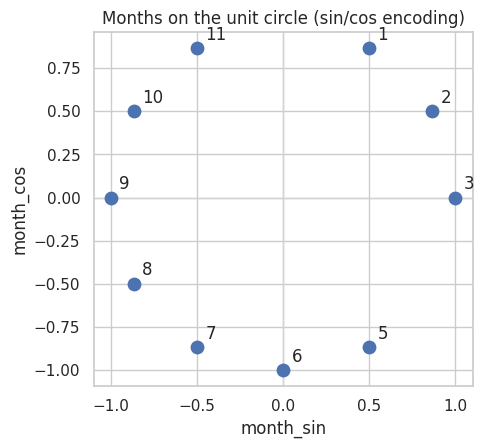

In [18]:
# A quick visual proof that the encoding does what we claim: plot every month
# on the unit circle and check that Dec and Jan really do sit next to each other.
fig, ax = plt.subplots(figsize=(5, 5))
month_points = df[["visit_month", "month_sin", "month_cos"]].drop_duplicates()
ax.scatter(month_points["month_sin"], month_points["month_cos"], s=80, zorder=3)
for _, row in month_points.iterrows():
    ax.annotate(int(row["visit_month"]), (row["month_sin"], row["month_cos"]),
                textcoords="offset points", xytext=(6, 6))
ax.set_title("Months on the unit circle (sin/cos encoding)")
ax.set_xlabel("month_sin"); ax.set_ylabel("month_cos")
ax.axhline(0, color="lightgray", lw=1); ax.axvline(0, color="lightgray", lw=1)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 6 · Feature splitting — compound columns

Two columns in this feed each secretly hold **two pieces of information**:

| Column         | Hidden features inside it        |
|----------------|-----------------------------------|
| `City(nature)` | city name **+** urban/local tag  |
| `Time`         | hour **+** minute                |

Splitting them out turns one blended signal into two independently useful
ones — e.g. you can now group by `Area_Type` alone, which you couldn't do
while it was fused into a text label.

In [19]:
# --- Split 'City(nature)' -> 'City' + 'Area_Type' via a named-group regex --
split_city = df["City(nature)"].str.extract(r"^(?P<City>[A-Za-z]+)\((?P<Area_Type>[A-Za-z]+)\)$")
df[["City", "Area_Type"]] = split_city
df[["City(nature)", "City", "Area_Type"]].drop_duplicates()

,City(nature),City,Area_Type
0,Yangon(Local),Yangon,Local
1,Naypyitaw(Local),Naypyitaw,Local
9,Mandalay(urban),Mandalay,urban


In [20]:
# --- Split 'Time' -> 'visit_hour' + 'visit_minute' + a readable bucket -----
time_parts = df["Time"].str.split(":", expand=True).astype(int)
df["visit_hour"]   = time_parts[0]
df["visit_minute"] = time_parts[1]

hour_bins   = [0, 12, 17, 21, 24]
hour_labels = ["Morning", "Afternoon", "Evening", "Night"]
df["time_of_day"] = pd.cut(df["visit_hour"], bins=hour_bins, labels=hour_labels,
                            right=False, include_lowest=True)

df[["Time", "visit_hour", "visit_minute", "time_of_day"]]

,Time,visit_hour,visit_minute,time_of_day
0,13:08,13,8,Afternoon
1,10:29,10,29,Morning
2,13:23,13,23,Afternoon
3,20:33,20,33,Evening
4,10:37,10,37,Morning
5,18:30,18,30,Evening
6,14:36,14,36,Afternoon
7,11:38,11,38,Morning
8,17:15,17,15,Evening
9,13:27,13,27,Afternoon


## 7 · Method showcase — same objective, several routes

The point of this section: **there is rarely only one "correct" way** to
extract a feature in pandas. Below, three different techniques all produce
the *same* month number, and two different techniques both split
`City(nature)`. Knowing the alternatives matters because they trade off
readability, performance, and robustness differently.

In [21]:
# --- Objective: get the calendar month as an integer, three ways ----------
month_via_dt        = df["date_visited"].dt.month                       # (1) vectorised accessor — fastest, idiomatic
month_via_strftime  = df["date_visited"].dt.strftime("%m").astype(int)  # (2) via string formatting — handy when you want zero-padded text too
month_via_apply     = df["date_visited"].apply(lambda d: d.month)       # (3) row-wise Python — most flexible, slowest

pd.DataFrame({
    "dt.month":  month_via_dt,
    "strftime":  month_via_strftime,
    "apply":     month_via_apply,
}).head()

,dt.month,strftime,apply
0,10,10,10
1,8,8,8
2,9,9,9
3,10,10,10
4,9,9,9


In [22]:
# Sanity check: all three routes must agree
assert (month_via_dt.values == month_via_strftime.values).all()
assert (month_via_dt.values == month_via_apply.values).all()
print("All three routes to 'month' agree.")
print("Preferred: .dt.month  ->  vectorised (runs on the whole column in C, "
      "not a Python loop) and clearest to read.")
print("Use .apply only when the transformation genuinely can't be vectorised.")

All three routes to 'month' agree.
Preferred: .dt.month  ->  vectorised (runs on the whole column in C, not a Python loop) and clearest to read.
Use .apply only when the transformation genuinely can't be vectorised.


In [23]:
# --- Objective: split 'City(nature)' into two columns, two ways -----------
# Route 1 (used above): regex with named capture groups — self-documenting,
# and returns both columns from a single call.
route1 = df["City(nature)"].str.extract(r"^(?P<City>[A-Za-z]+)\((?P<Area_Type>[A-Za-z]+)\)$")

# Route 2: no regex at all — plain string slicing. Faster to write for a
# simple, fixed pattern like "word(word)", but brittle the moment the format
# varies (extra spaces, nested parentheses, missing "(" etc.).
route2 = df["City(nature)"].str.replace(")", "", regex=False).str.split("(", expand=True)
route2.columns = ["City", "Area_Type"]

print("Regex route and split route agree:",
      route1.equals(route2))
route1.head(3)

Regex route and split route agree: True


,City,Area_Type
0,Yangon,Local
1,Naypyitaw,Local
2,Yangon,Local


## 8 · Business-ready wrap-up

A quick payoff to show *why* any of this mattered: with the engineered
columns in place, a question like *"do afternoon shoppers spend more than
morning shoppers?"* becomes a one-line group-by — something you could not
have asked of the raw `Time` string column. It's also only trustworthy
*because* Section 3 repaired the two corrupted `Total` values first; run
this on `df_raw` instead and the "Evening" figure would be wildly inflated
by a single bad row.

In [24]:
summary = (
    df.groupby("time_of_day", observed=True)["Total"]
      .agg(avg_spend="mean", n_transactions="count")
      .round(2)
      .sort_values("avg_spend", ascending=False)
)
summary

,avg_spend,n_transactions
time_of_day,,
Morning,449.59,6
Afternoon,423.31,6
Evening,326.07,7


In [25]:
print("Engineered columns added this notebook:")
new_cols = [c for c in df.columns if c not in df_raw.columns]
for c in new_cols:
    print(" -", c)
print(f"\nStarted with {df_raw.shape[1]} columns, finished with {df.shape[1]}.")

Engineered columns added this notebook:
 - gross_margin_pct
 - invoice_id_is_valid
 - visit_year
 - visit_month
 - visit_month_name
 - visit_quarter
 - visit_day
 - visit_day_name
 - visit_is_weekend
 - years_since_visit
 - days_since_visit
 - month_sin
 - month_cos
 - dow_sin
 - dow_cos
 - City
 - Area_Type
 - visit_hour
 - visit_minute
 - time_of_day

Started with 17 columns, finished with 36.


### Recap

- **Audited first** — found a header collision, a poisoned dtype, junk
  placeholder IDs, and a text date, all *before* writing a single fix.
- **Extracted** eight date-derived features from one `datetime` column,
  including reproducible recency and cyclical (sin/cos) encodings.
- **Split** two compound columns into four clean, independently useful ones.
- **Compared methods** for the same objective so the choice is a conscious
  trade-off, not the only line of code you happened to think of.

**Where this feeds next:** the cleaned, feature-rich `df` here is the right
input for the encoding techniques in `02_filtering_and_categorical_encoding.ipynb`
and `03_encoding_masterclass.ipynb` — extraction and splitting come first,
encoding comes after.

---

## Exam quick-reference

| To do this | Write this |
|---|---|
| Text → date | `pd.to_datetime(s, errors='coerce')` |
| Year / month / day | `s.dt.year` · `s.dt.month` · `s.dt.day` |
| Day name | `s.dt.day_name()` |
| Weekend flag | `s.dt.dayofweek >= 5` |
| Month label | `s.dt.to_period('M')` |
| Days between dates | `(a - b).dt.days` |
| Split on a character | `s.str.split('(', expand=True)` |
| Pull out a pattern | `s.str.extract(r'([A-Za-z]+)\\.')` |
| Contains / starts with | `s.str.contains('x')` · `.str.startswith('x')` |
| Length of the text | `s.str.len()` |
| Tidy text | `s.str.strip().str.lower()` |
| Ratio feature | `df['a'] / df['b'].replace(0, np.nan)` |
| Flag from a condition | `(df['a'] > 0).astype(int)` |

### Adapting this in the exam

- 'Extract the month/year from the date column' → `pd.to_datetime` first, then `.dt.month`.
- 'Split the column into two' → `.str.split(sep, expand=True)` gives you a DataFrame of parts.
- 'Create a new feature that…' → build it, then show a groupby of the target by that feature to demonstrate it carries signal.

### Traps that cost marks

- `.dt` only works on datetime columns and `.str` only on text columns. On the wrong dtype you get `AttributeError`.
- `pd.to_datetime` guesses the format. On ambiguous dates like `03/04/2025` state it: `format='%d/%m/%Y'`.
- Ratio features divide by zero. Use `.replace(0, np.nan)` on the denominator first.
- A feature built using the target column is leakage. Ask of every new feature: *would I know this before the outcome happened?*
- `str.extract` returns `NaN` where the pattern doesn't match — check how many before relying on it.
- More features is not better. A feature that duplicates an existing one adds multicollinearity, not information.